# hw4 - NN pyTorch

Во всем задании вы должны работать со входом из строк размером (длиной) 1024

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
# warnings.simplefilter('ignore')
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
from torchvision import transforms
from matplotlib import pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torch.autograd import Variable
from torchmetrics import Accuracy
import torch.nn.functional as F
from scipy import signal
acc = Accuracy()

## Часть 1 Фурье

### Подготовка данных

Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)

In [3]:
test = torch.from_numpy(np.fft.fft(np.sin(2*np.pi*np.arange(1024)/2)))
freq = np.fft.fftfreq(np.arange(1024).shape[-1])

In [4]:
test1 = torch.fft.fft(torch.sin(2*np.pi*torch.arange(1024)/2))
freq1 = torch.fft.fftfreq(torch.arange(1024).shape[-1])

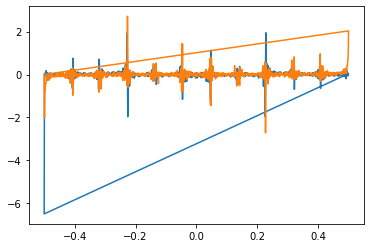

In [56]:
plt.plot(freq, test.real*1e11, freq, test.imag*1e11)

In [57]:
testing = torch.tensor([list(test.real*1e11), list(test.imag*1e11)]).transpose(0, 1)

In [58]:
testing.shape

torch.Size([1024, 2])

In [156]:
X_train, X_val, Y_train, Y_val = train_test_split(torch.sin(2*np.pi*torch.arange(1024)/4), testing, test_size = 0.1, random_state=30)

In [157]:
print("x_train shape",X_train.shape)
print("x_test shape",X_val.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_val.shape)

x_train shape torch.Size([921])
x_test shape torch.Size([103])
y_train shape torch.Size([921, 2])
y_test shape torch.Size([103, 2])


In [169]:
l = []

In [170]:
for i in range(1, 50):
    X_train, X_val, Y_train, Y_val = train_test_split(torch.sin(2*np.pi*torch.arange(1024)/4), testing, test_size = 0.1, random_state=i)
    l.append(abs(Y_train.mean().detach().numpy() - Y_val.mean().detach().numpy()))

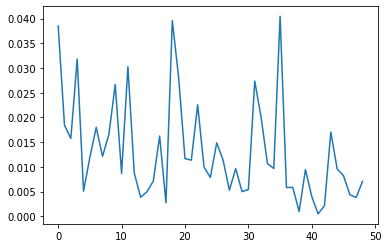

In [173]:
plt.plot(l)

In [174]:
X_train, X_val, Y_train, Y_val = train_test_split(torch.sin(2*np.pi*torch.arange(1024)/4), testing, test_size = 0.1, random_state=42)

In [175]:
print("x_train shape",X_train.shape)
print("x_test shape",X_val.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_val.shape)

x_train shape torch.Size([921])
x_test shape torch.Size([103])
y_train shape torch.Size([921, 2])
y_test shape torch.Size([103, 2])


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье

In [176]:
class Model(nn.Module):
    def __init__(self, input_dim, output_dim, h=5):
        super(Model, self).__init__()

        self.lin1 = nn.Linear(input_dim, h)
        self.lin2 = nn.Linear(h, h)
        self.lin3 = nn.Linear(h, output_dim)
        self.relu = nn.ReLU()
        self.s = nn.Softmax(dim=0)
        self.si = nn.Sigmoid()
    
    def forward(self, x):

        x = self.lin1(x)
        
        x = self.lin2(x)
        x = self.relu(x)
        x = self.lin2(x)
        x = self.relu(x)
        x = self.lin2(x)
        x = self.relu(x)

        x = self.lin3(x)

        return x

In [177]:
batch_size = 50
n_iters = 2000
num_epochs = int(n_iters / (1024 / batch_size))

train = TensorDataset(X_train, Y_train)
test = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = False)
    
model = Model(1, 2)

error = nn.L1Loss(size_average=None, reduce=None, reduction='mean')

optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum = 0.8)

In [178]:
loss_list = []
iteration_list = []
mse_list = []
count = 0
for epoch in range(num_epochs):
    for _, (batch, labels) in enumerate(train_loader):

        train  = Variable(batch.reshape(batch.shape[0], 1))
        labels = Variable(labels)
        
        optimizer.zero_grad()
        
        outputs = model(train)
        
        loss = error(outputs, labels.float())
        
        loss.backward()

        optimizer.step()
        
        count += 1
        if count % 20 == 0:
   
            correct = 0
            total = 0

            for _, (batch1, labels1) in enumerate(test_loader):
            
                test  = Variable(batch1.reshape(batch1.shape[0], 1))

                outputs = model(test)
                total += 1
                correct += mean_squared_error(outputs.reshape(outputs.shape[0]*outputs.shape[1]).detach().numpy(), labels1.reshape(outputs.shape[0]*outputs.shape[1]).detach().numpy())

            mse = correct / total

            loss_list.append(loss.data)
            iteration_list.append(count)
            mse_list.append(mse)
            if count % 200 == 0:
                print('Iteration: {}  Loss: {} mse: {} '.format(count, loss.item(), mse))

Iteration: 200  Loss: 0.14479365944862366 mse: 0.07163473769063562 
Iteration: 400  Loss: 0.09324637055397034 mse: 0.07138848846438195 
Iteration: 600  Loss: 0.10172288864850998 mse: 0.0715723529854183 
Iteration: 800  Loss: 0.122653529047966 mse: 0.0712852667750814 
Iteration: 1000  Loss: 0.08492720872163773 mse: 0.0714646535809517 
Iteration: 1200  Loss: 0.08699596673250198 mse: 0.07114936315813168 
Iteration: 1400  Loss: 0.10868798196315765 mse: 0.07148089677041668 
Iteration: 1600  Loss: 0.0847720131278038 mse: 0.07102895752557908 
Iteration: 1800  Loss: 0.13099707663059235 mse: 0.07140679457823125 


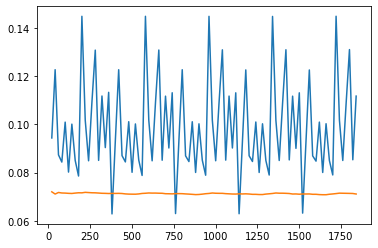

In [179]:
plt.plot(iteration_list, loss_list, iteration_list, np.array(mse_list))

### Сравните свое решение с пакетным методом

In [185]:
test2  = Variable((torch.sin(2*np.pi*torch.arange(1024)/2)).reshape(1024, 1))
out = model(test2)

In [186]:
test = torch.from_numpy(np.fft.fft(np.sin(2*np.pi*np.arange(1024)/2)))

In [187]:
out = out.transpose(0, 1)

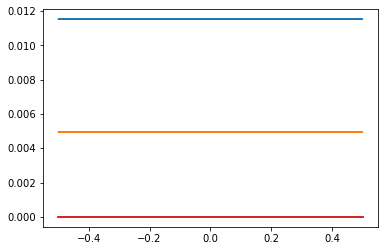

In [189]:

plt.plot(freq, out.data[0], freq, out.data[1], freq, test.real, freq, test.imag)

## Часть 2 Power spectral density (dB)

### Подготовка данных

Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.

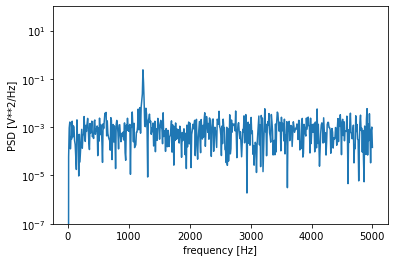

In [297]:
rng = np.random.default_rng()

fs = 10e3
N = 1024
amp = 2*np.sqrt(2)
freq = 1234.0
noise_power = 0.001 * fs / 2
time = np.arange(N) / fs
x = amp*np.sin(2*np.pi*freq*time)
x += rng.normal(scale=np.sqrt(noise_power), size=time.shape)
f, Pxx_den = signal.periodogram(x, fs)

plt.semilogy(f, Pxx_den)
plt.ylim([1e-7, 1e2])
plt.xlabel('frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

In [298]:
testing = torch.tensor([list(f)[1:], list(Pxx_den[1:])]).transpose(0, 1)

In [299]:
testing.shape

torch.Size([512, 2])

In [303]:
X_train, X_val, Y_train, Y_val = train_test_split(torch.Tensor(x).reshape(512, 2), testing, test_size = 0.1, random_state=2)

In [304]:
print("x_train shape",X_train.shape)
print("x_test shape",X_val.shape)
print("y_train shape",Y_train.shape)
print("y_test shape",Y_val.shape)

x_train shape torch.Size([460, 2])
x_test shape torch.Size([52, 2])
y_train shape torch.Size([460, 2])
y_test shape torch.Size([52, 2])


### Соберите и обучите нейросеть для предсказания спектральной плотности мощности

*Подсказка: для входа 1024 выход будет 512*

In [316]:
batch_size = 50
n_iters = 500
num_epochs = int(n_iters / (1024 / batch_size))

train = TensorDataset(X_train, Y_train)
test = TensorDataset(X_val, Y_val)

train_loader = DataLoader(train, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = False)
    
model = Model(2, 2)

error = F.mse_loss

optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

In [317]:
loss_list = []
iteration_list = []
mse_list = []
count = 0
for epoch in range(num_epochs):
    for _, (batch, labels) in enumerate(train_loader):

        train  = Variable(batch.reshape(batch.shape[0], batch.shape[1]))
        labels = Variable(labels)
        
        optimizer.zero_grad()
        
        outputs = model(train)
        
        loss = error(outputs, labels.float())
        
        loss.backward()

        optimizer.step()
        
        count += 1
        if count % 5 == 0:
   
            correct = 0
            total = 0

            for _, (batch1, labels1) in enumerate(test_loader):
            
                test  = Variable(batch1.reshape(batch1.shape[0], batch.shape[1]))

                outputs = model(test)
                total += 1
                correct += mean_squared_error(outputs.reshape(outputs.shape[0]*outputs.shape[1]).detach().numpy(), labels1.reshape(outputs.shape[0]*outputs.shape[1]).detach().numpy())

            mse = correct / total

            loss_list.append(loss.data)
            iteration_list.append(count)
            mse_list.append(mse)
            if count % 50 == 0:
                print('Iteration: {}  Loss: {}  mse: {} '.format(count, loss.detach().numpy(), mse))

Iteration: 50  Loss: 3779378.0  mse: 3464018.8217184437 
Iteration: 100  Loss: 3779378.0  mse: 3464018.821717133 
Iteration: 150  Loss: 3779378.0  mse: 3464018.8217171174 
Iteration: 200  Loss: 3779378.0  mse: 3464018.821717117 


### Провалидируйте свое решение

*Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением*

In [323]:
test2  = Variable(torch.Tensor(x).reshape(512, 2))
out = model(test2)

In [324]:
out = out.transpose(0, 1)

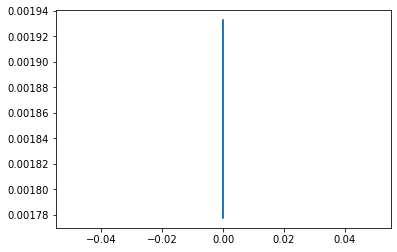

In [329]:
plt.plot(out.data[0], out.data[1])